# AI Club: Intro to Python & Build Your First ML Model Workshop Fall 2026 ✨

**Welcome to the first workshop of the 2026-2027 school year for the SDSU AI Club!**

Over the next hour, you'll go from a dataset to a trained machine learning model by following the same high-level workflow used in real machine learning projects.

By the end of this workshop, you'll have trained your first model, evaluated its performance, and built another model on your own using a different dataset.

In this workshop, we will:


- Remove the fear of machine learning.
- Learn the core tools used by ML engineers.
- Follow the machine learning pipeline from data to prediction.
- Train, evaluate, and build your first machine learning model.

Throughout this workshop, we'll answer questions like:
- What is a machine learning model?
- What are features (X) and labels (y)?
- How does a computer learn from data?
- How do we know if our model is actually working?
- How can we reuse the same workflow on completely different datasets?





###Machine Learning Pipeline
```text
Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment
                   
```

# Step 1: Business Understanding

The first step in any machine learning project is understanding **the problem we're trying to solve** and **why machine learning is the right tool**.

For this workshop, we'll use the **`banknote_authentication.csv`** dataset from the UCI Machine Learning Repository. This dataset contains numerical measurements extracted from images of genuine and counterfeit banknotes, including **variance, skewness, curtosis, and entropy**.

Each banknote is also assigned a **class** indicating whether it is genuine or counterfeit.

Our goal is to answer the following question:

> **Can we build a machine learning model that determines whether a banknote is genuine or counterfeit based on its features?**

# Step 2: Understanding Your Data

Before we can train a machine learning model, we first need to understand the data we're working with.

In this step, we'll perform **Exploratory Data Analysis (EDA)**—a fancy way of saying **we're going to explore our data**. We'll take a look at the dataset, understand what each feature represents, inspect its structure, and verify that it's ready to be used for machine learning.

> **Workshop Note**
>
> For today's workshop, I intentionally chose a dataset that is **clean**, **contains only numerical features**, and is **small enough** to work well with the Decision Tree model we'll be training. This allows us to focus on learning the machine learning pipeline rather than spending time cleaning data.
>
> In real-world machine learning projects, datasets are rarely this clean. You'll often encounter missing values, incorrect data types, duplicate records, outliers, and categorical features that must be transformed before a model can be trained. This process is called **data preprocessing**, and it's one of the most important parts of any machine learning project. We'll cover these techniques in a future workshop.

### Library Overview

- **Pandas** – Load and work with tabular data.
- **Matplotlib** – Create visualizations.
- **Seaborn** – Create cleaner statistical visualizations.
- **Scikit-Learn** – Train and evaluate machine learning models.

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [34]:
#read the dataset from the AI Club Repo
df = pd.read_csv(
    "https://raw.githubusercontent.com/aiclub-sdsu/workshops/main/Fall26/datasets/banknote_authentication.csv"
)

In [35]:
df.shape #this function tells us how many (rows, columns) in the dataset

(1372, 5)

In [36]:
df.head() #returns the first 5 rows

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [37]:
df.columns

Index(['variance', 'skewness', 'curtosis', 'entropy', 'class'], dtype='object')

In [38]:
df.isna().sum() #check for missing values

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [39]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


# Step 3: Preparing Your Data

Our dataset is already clean, numerical, and contains a binary label, so very little preprocessing is required.

Before training, we'll separate our dataset into:

- **Features (X):** The measurements our model will use to make predictions.
- **Label (y):** Whether the banknote is genuine or counterfeit.

In real-world projects, this step often requires significantly more preprocessing.

> ## 📝 Workshop Note
>
> The preprocessing step we performed today was intentionally simple. In real-world machine learning projects, data preprocessing is often the **most time-consuming** part of the entire workflow.
>
> Depending on the dataset, you may need to:
>
> - Handle missing values
> - Remove duplicate records
> - Correct incorrect data types
> - Detect and handle outliers
> - Encode categorical features (One-Hot Encoding)
> - Scale or normalize numerical features
> - Engineer new features
>
> Today, we chose a clean dataset so we could focus on understanding the machine learning pipeline. We'll cover these preprocessing techniques in a future workshop.
>
> **Resources to Learn More**
>
> - 📖 Scikit-Learn User Guide – https://scikit-learn.org/stable/user_guide.html
> - 📖 Pandas Documentation – https://pandas.pydata.org/docs/
> - 📖 Kaggle Learn: Data Cleaning – https://www.kaggle.com/learn/data-cleaning

In [40]:
# Define our features and label
y = df["class"]
X = df.drop(columns=["class"])

#Step 4: Train your Model

Now that our data has been prepared, we're ready to train our first machine learning model.

Before a model can make predictions, it must first **learn** from examples. This learning process is called **training**.

To do this, we'll first separate our data into:

- **Features (X):** The information the model will use to make predictions.
- **Label (y):** The value we want the model to predict.

Next, we'll split our data into a **training set** and a **testing set**. The model will learn patterns from the training data, and we'll later evaluate how well it performs on data it has never seen before.

Finally, we'll train a **Decision Tree Classifier**, which learns a series of decision rules from the training data to classify new examples.

## What is a Decision Tree?

A **Decision Tree** is a machine learning model that learns a series of questions from the training data. Each question splits the data into smaller and smaller groups until the model reaches a prediction.

A simplified Decision Tree might look like this:

```text
                         Variance > 0.5?
                        /               \
                      Yes                No
                     /                    \
             Skewness > 3.0?        Entropy > -1.0?
               /       \              /         \
             Yes       No           Yes          No
              ↓         ↓             ↓           ↓
          Genuine  Counterfeit   Genuine    Counterfeit
```

Notice that every branch asks a question, and every leaf (the final node) represents the model's prediction.

The goal of training is to allow the computer to automatically discover the best questions to ask.

In [41]:
# Split our data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
# Create the model
model = DecisionTreeClassifier(random_state=42)

In [43]:
# Train the model
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# Step 5: Evaluating Our Model

Now that our model has been trained, it's time to see how well it performs.

To evaluate our model, we'll ask it to predict whether banknotes it has **never seen before** are genuine or counterfeit.

We'll then compare those predictions to the actual labels and calculate the model's **accuracy**.

**Accuracy** measures the percentage of predictions our model got correct.

A higher accuracy generally means our model is making better predictions.

In [44]:
y_pred = model.predict(X_test)

In [45]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 98.18%


## Improving and Testing Our Model

Our first model gives us a baseline. To improve it, we can adjust a model setting called a **hyperparameter**.

For a Decision Tree, one useful hyperparameter is `max_depth`, which controls how many levels deep the tree can grow.

A deeper tree can learn more patterns, but it can also become too specific to the training data. A smaller tree is simpler, but it might miss important patterns.

In [46]:
# Test different values of max_depth
depths = [2, 3, 4, 5, 6, 8, 10]

results = []

for depth in depths:

    # Create a new model
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)

    # Save the results
    results.append(accuracy)

    print(f"Max Depth = {depth} | Accuracy = {accuracy:.2%}")

Max Depth = 2 | Accuracy = 88.00%
Max Depth = 3 | Accuracy = 90.91%
Max Depth = 4 | Accuracy = 93.45%
Max Depth = 5 | Accuracy = 96.73%
Max Depth = 6 | Accuracy = 97.82%
Max Depth = 8 | Accuracy = 98.18%
Max Depth = 10 | Accuracy = 98.18%


In [47]:
results_df = pd.DataFrame({
    "Max Depth": depths,
    "Accuracy": results
})

results_df

,Max Depth,Accuracy
0,2,0.880000
1,3,0.909091
2,4,0.934545
3,5,0.967273
4,6,0.978182
5,8,0.981818
6,10,0.981818


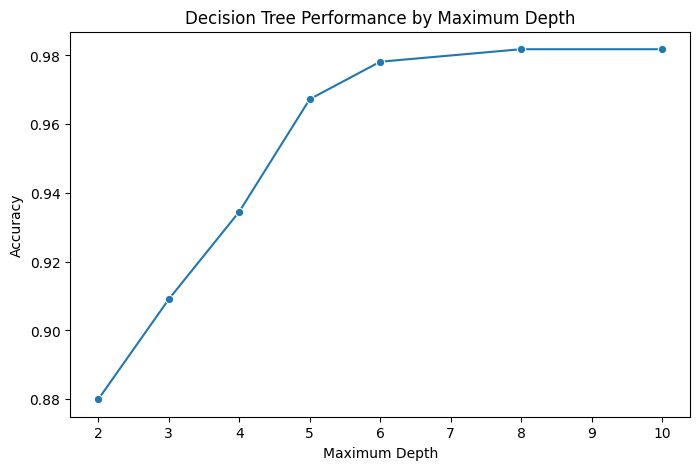

In [48]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=results_df,
    x="Max Depth",
    y="Accuracy",
    marker="o"
)

plt.title("Decision Tree Performance by Maximum Depth")
plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")

plt.show()

In [49]:
best_depth = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Max Depth"
]

print(f"Best max_depth: {best_depth}")

Best max_depth: 8


In [50]:
best_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

best_model.fit(X_train, y_train)

best_predictions = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, best_predictions)

print(f"Best Model Accuracy: {best_accuracy:.2%}")

Best Model Accuracy: 98.18%


## Using Our Model on New Data

Now that we have trained and improved our model, we can use it to make predictions on new banknote samples.

This is the whole point of training a machine learning model: once it has learned patterns from past data, we can give it new information and ask it to make a prediction.
> The model does not know the true class of this new sample. It only sees the banknote's numerical features and uses the patterns it learned during training to make a prediction.

In [51]:
# Create a new banknote sample
new_banknote = pd.DataFrame({
    "variance": [3.62],
    "skewness": [8.67],
    "curtosis": [-2.81],
    "entropy": [-0.45]
})

In [52]:
# Use the model to make a prediction
prediction = best_model.predict(new_banknote)[0]

labels = {
    0: "Counterfeit Banknote 🚫",
    1: "Genuine Banknote 💵"
}

print("Prediction:", labels[prediction])

Prediction: Counterfeit Banknote 🚫


> The model does not know the original quality score for this new sample. It only sees the chemical properties and uses the patterns it learned during training to make a prediction.

# Step 6: Deployment

Once we've trained a model that performs well, the next step is **deployment**.

Deployment simply means making our model available for other people or applications to use.

Instead of running predictions from inside a Jupyter Notebook, we could integrate our model into:

- 🌐 A website
- 📱 A mobile application
- ☁️ A cloud service or API
- 🏢 A company's internal software

Once deployed, users can provide new data, and the model can instantly return a prediction.

This is how many of the AI-powered applications we use every day work.

          User Input
               │
               ▼
      Trained ML Model
               │
               ▼
         Prediction

# 🎉 Congratulations!

Today you completed an end-to-end machine learning workflow.

You learned how to:

✅ Understand a machine learning problem

✅ Explore and prepare a dataset

✅ Train a Decision Tree model

✅ Evaluate its performance

✅ Improve the model by tuning a hyperparameter

✅ Use the trained model to make predictions on new data

✅ Understand how trained models are deployed into real-world applications

Although today's dataset was intentionally clean and simple, the same workflow is used by machine learning engineers to solve real-world problems across healthcare, finance, cybersecurity, recommendation systems, and many other industries.